# 《飞驰人生3》短评 —— 情感分析

**数据来源**：豆瓣短评（已清洗）  
**输入文件**：`飞驰人生3_cleaned.csv`  
**标签字段**：`comment_type`（1=好评, 0=中评, -1=差评）  

---

### 分析思路

| 层次 | 目标 | 方法 |
|------|------|------|
| 可视化层 | 直觉感知三类差异 | 词云、高频词对比柱状图 |
| 特征分析层 | 量化差异 | TF-IDF 区分度、文本统计特征、PMI 情感得分 |
| 统计验证层 | 证明差异显著 | 卡方检验、Kruskal-Wallis 检验 |

## 0. 导入依赖库

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import re
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams["font.family"] = "SimHei"
matplotlib.rcParams["axes.unicode_minus"] = False

## 1. 配置区

In [2]:
INPUT_FILE = "../../2.预处理/飞驰人生3_cleaned.csv"
FONT_PATH  = "C:/Windows/Fonts/simhei.ttf"
RANDOM_STATE = 42

# 三类颜色方案
TYPE_META = {
    1:  {"label": "好评", "color": "#2ECC71", "cmap": "Greens"},
    0:  {"label": "中评", "color": "#F39C12", "cmap": "Oranges"},
    -1: {"label": "差评", "color": "#E74C3C", "cmap": "Reds"},
}

type_order = [1, 0, -1]
type_labels = [TYPE_META[t]["label"] for t in type_order]
type_colors_list = [TYPE_META[t]["color"] for t in type_order]

## 2. 加载数据 & 概览

In [3]:
df = pd.read_csv(INPUT_FILE, encoding="utf-8-sig")
df["tokens"] = df["tokens"].fillna("")

print(f"总评论数：{len(df)}")
print(f"\n各类别分布：")
for t, meta in TYPE_META.items():
    n = (df["comment_type"] == t).sum()
    print(f"  {meta['label']}（{t}）：{n} 条  ({n/len(df)*100:.1f}%)")

df.head()

总评论数：1186

各类别分布：
  好评（1）：399 条  (33.6%)
  中评（0）：396 条  (33.4%)
  差评（-1）：391 条  (33.0%)


,movie_name,comment_type,comment_text,tokens,rating,votes_count,is_high_vote,created_at,comment_date,time_period,comment_length,source_page
0,飞驰人生3,1,目前系列最佳，非常纯粹的赛车电影。文戏精炼克制，讽刺意味却丝毫未减。赛车戏占比大幅提高，镜头...,目前 系列 最佳 非常 纯粹 赛车 文戏 精炼 克制 讽刺 意味 丝毫 未减 赛车 大幅提高...,5,4558,1,2026-02-17 12:10:51,2026-02-17,下午,113,1
1,飞驰人生3,1,韩寒写了部真正的中国侠客故事，事了拂衣去，干干净净赢。,韩寒 真正 中国 侠客 故事 拂衣 干干净净,4,4214,1,2026-02-17 11:11:34,2026-02-17,上午,27,1
2,飞驰人生3,1,这次赛车戏量大管饱，三部之最，且在前两部的基础上做了升级，作为洲际比赛的沐尘100拉力赛，比...,这次 赛车 戏量 管饱 三部 两部 基础 升级 作为 洲际 比赛 沐尘100 拉力赛 比巴音...,4,2723,1,2026-02-17 11:13:31,2026-02-17,上午,175,1
3,飞驰人生3,1,完全超乎我的预料，简直屌炸天！,完全 超乎 预料 简直 炸天,5,2526,1,2026-02-17 11:09:03,2026-02-17,上午,15,1
4,飞驰人生3,1,这个系列每一步都走得很扎实，第一部讲求生，第二部讲求胜，第三部整个格局和立意都打开，在具备高...,系列 一步 扎实 第一部 讲求 第二部 讲求 第三部 整个 格局 立意 打开 具备 高度 赛...,4,1710,1,2026-02-17 11:14:48,2026-02-17,上午,258,1


## 3. 文本统计特征分析

### 指标设计

| 指标 | 含义 | 选取理由 |
|------|------|----------|
| 评论字数 | 原始文本长度 | 反映表达意愿的强弱 |
| 分词词数 | 有效词语数量 | 衡量信息密度 |
| 平均句长 | 词数 / 句子数 | 反映句式复杂度和论述深度 |

In [4]:
# 3.1 计算文本统计特征
df["char_len"] = df["comment_text"].str.len()
df["word_count"] = df["tokens"].apply(lambda x: len(x.split()) if x else 0)

def avg_sentence_length(text, tokens_str):
    """平均句长 = 总词数 / 句子数"""
    sentences = re.split(r"[。！？；…]+", text)
    sentences = [s for s in sentences if s.strip()]
    n_sent = max(len(sentences), 1)
    n_words = len(tokens_str.split()) if tokens_str else 0
    return n_words / n_sent

df["avg_sent_len"] = df.apply(
    lambda r: avg_sentence_length(str(r["comment_text"]), str(r["tokens"])),
    axis=1
)

stat_cols   = ["char_len", "word_count", "avg_sent_len"]
stat_labels = ["评论字数", "分词词数", "平均句长"]

# 3.2 各指标均值一览
print("各类评论文本统计特征均值：")
print("-" * 75)
print(f"{'指标':<14s}", end="")
for t in type_order:
    print(f"  {TYPE_META[t]['label']:>8s}", end="")
print()
print("-" * 75)
for col, label in zip(stat_cols, stat_labels):
    print(f"{label:<14s}", end="")
    for t in type_order:
        val = df[df["comment_type"] == t][col].mean()
        print(f"  {val:>8.2f}", end="")
    print()

各类评论文本统计特征均值：
---------------------------------------------------------------------------
指标                    好评        中评        差评
---------------------------------------------------------------------------
评论字数               98.52     67.96     58.50
分词词数               29.50     20.21     17.14
平均句长               11.24      9.48      8.01


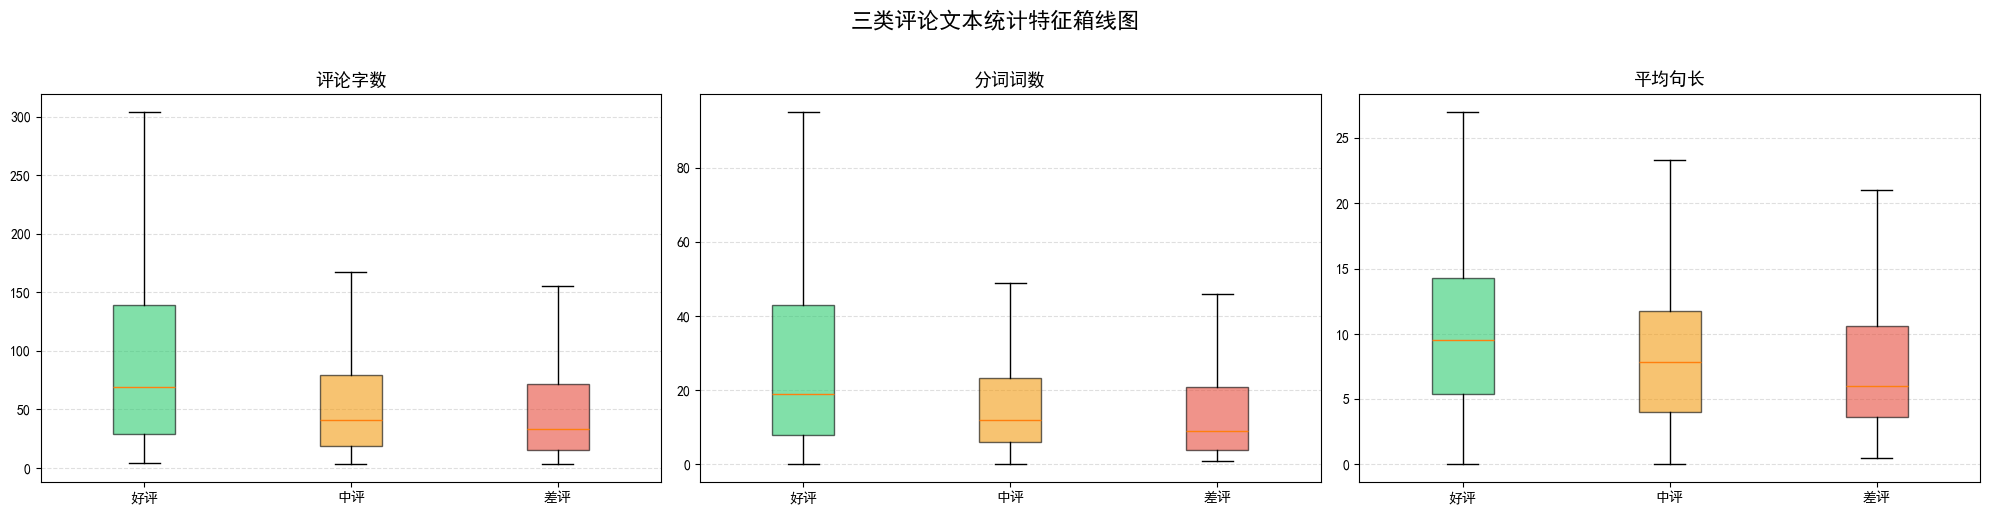

✅ 已保存：文本统计特征_箱线图.png


In [5]:
# 3.3 箱线图
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (col, label) in enumerate(zip(stat_cols, stat_labels)):
    data_groups = [df[df["comment_type"] == t][col].values for t in type_order]
    bp = axes[i].boxplot(data_groups, labels=type_labels,
                         patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], type_colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[i].set_title(label, fontsize=13)
    axes[i].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("三类评论文本统计特征箱线图", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("文本统计特征_箱线图.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 已保存：文本统计特征_箱线图.png")

In [6]:
# 3.4 Kruskal-Wallis 检验
print("=" * 70)
print("Kruskal-Wallis 检验（三类评论文本统计特征）")
print("=" * 70)
print(f"{'指标':<16s}  {'H统计量':>10s}  {'p值':>12s}  {'结论':>8s}")
print("-" * 70)

for col, label in zip(stat_cols, stat_labels):
    groups = [df[df["comment_type"] == t][col].values for t in type_order]
    h_stat, p_val = stats.kruskal(*groups)
    sig = ("显著 ***" if p_val < 0.001 else
           ("显著 **" if p_val < 0.01 else
           ("显著 *" if p_val < 0.05 else "不显著")))
    print(f"{label:<16s}  {h_stat:>10.2f}  {p_val:>12.2e}  {sig:>8s}")

print("-" * 70)
print("注：显著性水平 * p<0.05  ** p<0.01  *** p<0.001")

Kruskal-Wallis 检验（三类评论文本统计特征）
指标                      H统计量            p值        结论
----------------------------------------------------------------------
评论字数                   67.42      2.29e-15    显著 ***
分词词数                   69.11      9.82e-16    显著 ***
平均句长                   51.15      7.83e-12    显著 ***
----------------------------------------------------------------------
注：显著性水平 * p<0.05  ** p<0.01  *** p<0.001


## 4. 基于 PMI 的情感分析

### 4.1 PMI 情感词典构建

**Pointwise Mutual Information（逐点互信息）** 衡量一个词与某类别的关联强度：

$$\text{PMI}(w, c) = \log_2 \frac{P(w, c)}{P(w) \cdot P(c)}$$

- PMI > 0 表示该词与该类别**正相关**（共现频率高于随机预期）
- PMI = 0 表示独立
- PMI < 0 表示**负相关**

我们计算每个词与好评类（1）和差评类（-1）的 PMI 值，
取 PMI\_好评 最高的词作为正面情感词，PMI\_差评 最高的词作为负面情感词。

**优势**：完全数据驱动，不需要人工指定词典，且能捕捉到领域特有的情感表达。

In [7]:
# ── 4.1.1 构建词-文档出现矩阵 ──

# 用 CountVectorizer 统计每个词在每条评论中是否出现（二值化）
cv = CountVectorizer(min_df=3, max_df=0.95, max_features=1000, binary=True)
X_binary = cv.fit_transform(df["tokens"])
vocab = cv.get_feature_names_out()

N = len(df)  # 总文档数

# ── 4.1.2 计算 PMI ──

def calc_pmi_for_class(X_bin, labels, target_class, vocab, min_count=5):
    """
    计算每个词与 target_class 的 PMI。
    X_bin: 二值化词-文档矩阵 (n_docs, n_vocab)
    labels: 类别标签数组
    target_class: 目标类别值
    返回: {word: pmi_value} 字典
    """
    N = X_bin.shape[0]
    mask_c = (labels == target_class)
    n_c = mask_c.sum()              # 属于 target_class 的文档数
    p_c = n_c / N                   # P(c)

    # 每个词的文档频率
    word_doc_freq = np.array(X_bin.sum(axis=0)).flatten()  # P(w) * N
    # 每个词在 target_class 中的文档频率
    word_class_freq = np.array(X_bin[mask_c].sum(axis=0)).flatten()  # P(w,c) * N

    pmi_dict = {}
    for i, word in enumerate(vocab):
        n_w = word_doc_freq[i]
        n_wc = word_class_freq[i]
        if n_w < min_count or n_wc < 1:
            continue
        p_w = n_w / N
        p_wc = n_wc / N
        pmi = np.log2(p_wc / (p_w * p_c))
        pmi_dict[word] = round(pmi, 4)

    return pmi_dict

labels = df["comment_type"].values

pmi_pos = calc_pmi_for_class(X_binary, labels, target_class=1,  vocab=vocab)
pmi_neg = calc_pmi_for_class(X_binary, labels, target_class=-1, vocab=vocab)

# 按 PMI 降序排列
pmi_pos_sorted = sorted(pmi_pos.items(), key=lambda x: -x[1])
pmi_neg_sorted = sorted(pmi_neg.items(), key=lambda x: -x[1])

print("=" * 60)
print("PMI 自动挖掘的情感词（Top 25）")
print("=" * 60)
print(f"\n{'正面情感词（PMI_好评 Top25）':<20s}  {'负面情感词（PMI_差评 Top25）'}")
print("-" * 60)

import unicodedata
# 计算字符实际显示宽度（中文=2，英文=1）
def get_width(s):
    return sum(2 if unicodedata.east_asian_width(c) in 'WF' else 1 for c in str(s))

# 固定总宽度，自动补齐空格
def pad_to_width(s, width):
    s = str(s)
    w = get_width(s)
    return s + ' ' * (width - w)

for i in range(25):
    pw, pv = pmi_pos_sorted[i] if i < len(pmi_pos_sorted) else ("", 0)
    nw, nv = pmi_neg_sorted[i] if i < len(pmi_neg_sorted) else ("", 0)
    print(f"{pad_to_width(pw, 12)}"f"{pv:>7.3f}"f"            {pad_to_width(nw, 12)}"f"{nv:>7.3f}")

PMI 自动挖掘的情感词（Top 25）

正面情感词（PMI_好评 Top25）   负面情感词（PMI_差评 Top25）
------------------------------------------------------------
cp            1.572            圈钱          1.601
get           1.572            垃圾          1.408
一句          1.572            烂片          1.408
不服输        1.572            浪费          1.379
主创          1.572            复制粘贴      1.338
从巴音        1.572            油腻          1.338
保持          1.572            眼睛          1.338
再次          1.572            优势          1.279
反转          1.572            别拍          1.279
可谓          1.572            好歹          1.279
地形          1.572            气质          1.279
孙宇强        1.572            流水线        1.279
开心          1.572            离谱          1.279
拉满          1.572            区别          1.222
推荐          1.572            难看          1.205
最难          1.572            20            1.186
有力          1.572            小品          1.186
柏油路        1.572            睡着          1.153
洲际          1.572            全

### 4.2 基于 PMI 的情感得分计算

对每条评论，用 PMI 词典计算情感得分：

$$\text{Score}(d) = \frac{1}{|d|} \sum_{w \in d} \bigl(\text{PMI}(w, \text{好评}) - \text{PMI}(w, \text{差评})\bigr)$$

- 得分 > 0 偏正面，< 0 偏负面
- 每个词的贡献由数据决定，而非人工赋值

In [8]:
def pmi_sentiment_score(tokens_str, pmi_pos_dict, pmi_neg_dict):
    """
    计算单条评论的 PMI 情感得分。
    = mean( PMI_pos(w) - PMI_neg(w) ) for each word w in doc
    同时返回正面词命中数和负面词命中数。
    """
    words = tokens_str.split() if tokens_str else []
    if not words:
        return pd.Series({"pmi_score": 0.0, "pos_hits": 0, "neg_hits": 0,
                           "pos_ratio": 0.0, "neg_ratio": 0.0})

    score_sum = 0.0
    pos_hits = 0
    neg_hits = 0
    for w in words:
        p = pmi_pos_dict.get(w, 0)
        n = pmi_neg_dict.get(w, 0)
        diff = p - n
        score_sum += diff
        if p > 0.3 and p > n:
            pos_hits += 1
        if n > 0.3 and n > p:
            neg_hits += 1

    n_words = len(words)
    return pd.Series({
        "pmi_score": score_sum / n_words,
        "pos_hits": pos_hits,
        "neg_hits": neg_hits,
        "pos_ratio": pos_hits / n_words,
        "neg_ratio": neg_hits / n_words,
    })

sent_df = df["tokens"].apply(
    lambda x: pmi_sentiment_score(x, pmi_pos, pmi_neg)
)
df["pmi_score"] = sent_df["pmi_score"]
df["pos_ratio"] = sent_df["pos_ratio"]
df["neg_ratio"] = sent_df["neg_ratio"]

print("各类评论 PMI 情感得分均值：")
print("-" * 65)
for t in type_order:
    meta = TYPE_META[t]
    sub = df[df["comment_type"] == t]
    print(f"  {meta['label']}：PMI得分={sub['pmi_score'].mean():>+.4f}  "
          f"正面词占比={sub['pos_ratio'].mean():.4f}  "
          f"负面词占比={sub['neg_ratio'].mean():.4f}")

各类评论 PMI 情感得分均值：
-----------------------------------------------------------------
  好评：PMI得分=+0.6846  正面词占比=0.4320  负面词占比=0.0529
  中评：PMI得分=+0.3350  正面词占比=0.2719  负面词占比=0.0770
  差评：PMI得分=-0.0548  正面词占比=0.1875  负面词占比=0.2145


### 4.3 PMI 情感得分分布（小提琴图）

小提琴图同时展示分布形状和中位数，
直观呈现三类评论在 PMI 情感得分上的分布差异。

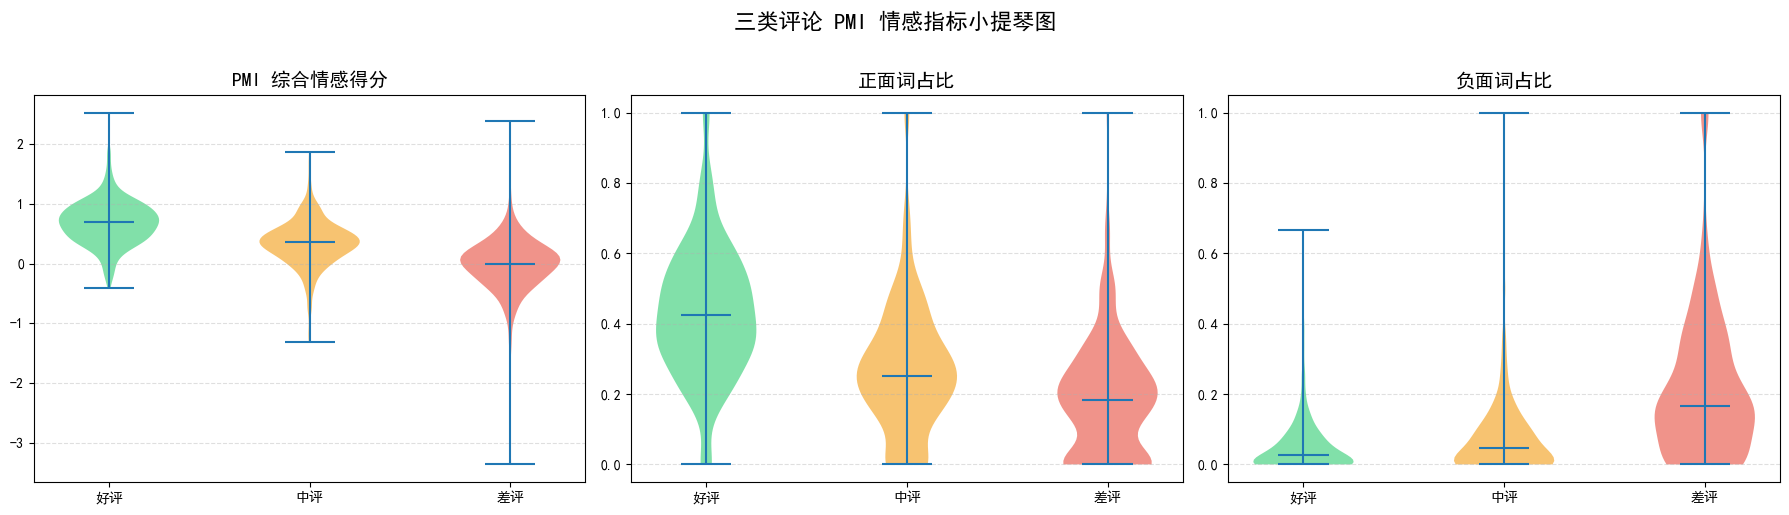

✅ 已保存：PMI情感得分_小提琴图.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sent_cols   = ["pmi_score", "pos_ratio", "neg_ratio"]
sent_labels = ["PMI 综合情感得分", "正面词占比", "负面词占比"]

for i, (col, label) in enumerate(zip(sent_cols, sent_labels)):
    data_groups = [df[df["comment_type"] == t][col].values for t in type_order]
    vp = axes[i].violinplot(data_groups, positions=[1, 2, 3], showmedians=True)
    for j, body in enumerate(vp["bodies"]):
        body.set_facecolor(type_colors_list[j])
        body.set_alpha(0.6)
    axes[i].set_xticks([1, 2, 3])
    axes[i].set_xticklabels(type_labels)
    axes[i].set_title(label, fontsize=14)
    axes[i].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("三类评论 PMI 情感指标小提琴图", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("PMI情感得分_小提琴图.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 已保存：PMI情感得分_小提琴图.png")

### 4.3 PMI分数最极端的好评和差评

情感分数最高的差评：comment_type == -1 中 pmi_score 最大的若干条 → 语言偏正面却被打了低分的评论（常见于反讽、"可惜/失望"式表达、或打分极严格的观众）

情感分数最低的好评：comment_type == 1 中 pmi_score 最小的若干条 → 语言偏负面却给了高分（常见于"吐槽式夸奖"、先抑后扬、或 1 星党互动）

In [10]:
TOP_N = 8

# 差评中 PMI 得分最高的 TOP_N 条（语言偏正面的差评）
neg_high = (df[df["comment_type"] == -1]
            .nlargest(TOP_N, "pmi_score")
            [["comment_text", "pmi_score", "pos_ratio", "neg_ratio", "word_count"]]
            .reset_index(drop=True))
pos_high = (df[df["comment_type"] == 1]
            .nlargest(TOP_N, "pmi_score")
            [["comment_text", "pmi_score", "pos_ratio", "neg_ratio", "word_count"]]
            .reset_index(drop=True))

# 好评中 PMI 得分最低的 TOP_N 条(语言偏负面的好评)
pos_low  = (df[df["comment_type"] == 1]
            .nsmallest(TOP_N, "pmi_score")
            [["comment_text", "pmi_score", "pos_ratio", "neg_ratio", "word_count"]]
            .reset_index(drop=True))
neg_low  = (df[df["comment_type"] == -1]
            .nsmallest(TOP_N, "pmi_score")
            [["comment_text", "pmi_score", "pos_ratio", "neg_ratio", "word_count"]]
            .reset_index(drop=True))

def print_extremes(sub_df, title, color_tag):
    # 定义颜色代码
    color = ""
    end_color = "\033[0m"  # 重置颜色
    
    if color_tag == "green":
        color = "\033[92m"  # 亮绿色
    elif color_tag == "red":
        color = "\033[91m"  # 亮红色

    print("=" * 90)
    # 标题带上颜色
    print(f"{color}【{title}】Top {len(sub_df)}{end_color}")
    print("=" * 90)
    print(f"{'#':>2s}  {'PMI得分':>6s}  {'正面词占比':>6s}  {'负面词占比':>6s}    评论内容")
    print("-" * 90)
    for i, row in sub_df.iterrows():
        text = str(row["comment_text"]).replace("\n", " ")
        if len(text) > 60:
            text = text[:60] + "…"
        # 每一行数据都带上颜色
        print(f"{color}{i+1:>2d}  {row['pmi_score']:>+8.4f}  "
              f"{row['pos_ratio']:>8.3f}  {row['neg_ratio']:>10.3f}     {text}{end_color}")
    print()


print_extremes(pos_high, "语言偏正面的好评（标签=+1, PMI得分最高）", "green")
print_extremes(pos_low,  "语言偏负面的好评（标签=+1, PMI得分最低）", "red")


【语言偏正面的好评（标签=+1, PMI得分最高）】Top 8
 #   PMI得分   正面词占比   负面词占比    评论内容
------------------------------------------------------------------------------------------
 1   +2.5187     1.000       0.000     永远不回头！
 2   +2.5187     1.000       0.000     永远不回头！
 3   +1.8968     1.000       0.000     又见系列电影
 4   +1.8515     0.636       0.000     张驰没有顶配的装备，却有最滚烫的热爱，永远敬热爱也敬不停向前，飞驰还是那个飞驰。
 5   +1.8422     1.000       0.000     保持了这个系列的水准。
 6   +1.7960     0.800       0.000     林臻东属于发挥稳定的顶级选手，张弛属于肾上腺素型选手。
 7   +1.6971     0.667       0.000     太燃了，果然纯粹的热爱才是最令人动容的！
 8   +1.5972     0.600       0.000     速度与激情还是很燃每次冲线的过程期待第四部去打欧美战队

【语言偏负面的好评（标签=+1, PMI得分最低）】Top 8
 #   PMI得分   正面词占比   负面词占比    评论内容
------------------------------------------------------------------------------------------
 1   -0.4011     0.333       0.333     同样的套路，但是就吃这一套
 2   -0.3353     0.000       0.333     现在的评分很符合。
 3   -0.2886     0.000       0.667     黄景瑜已经可以考究演技了
 4   -0.2574     0.000       0.500     Get到了黄景瑜
 5   -0.2264     0

In [11]:
print_extremes(neg_low,  "语言偏负面的差评（标签=-1, PMI得分最低）", "red")
print_extremes(neg_high, "语言偏正面的差评（标签=-1, PMI得分最高）", "green")

【语言偏负面的差评（标签=-1, PMI得分最低）】Top 8
 #   PMI得分   正面词占比   负面词占比    评论内容
------------------------------------------------------------------------------------------
 1   -3.3512     0.000       1.000     好无聊。
 2   -3.3512     0.000       1.000     无聊哎
 3   -3.3512     0.000       1.000     好无聊
 4   -2.6922     0.000       1.000     太难看了
 5   -2.3512     0.000       1.000     就那样
 6   -2.2523     0.000       1.000     太无聊了，要睡着了
 7   -1.6172     0.000       0.500     极度无聊的片子，三部都很无聊
 8   -1.3461     0.000       0.500     我的天呐这也太难看了

【语言偏正面的差评（标签=-1, PMI得分最高）】Top 8
 #   PMI得分   正面词占比   负面词占比    评论内容
------------------------------------------------------------------------------------------
 1   +2.3728     1.000       0.000     飞驰3比飞驰2差了4个飞驰1
 2   +1.3155     0.571       0.000     感想是这是韩寒写给陈思诚最美的一封情书
 3   +1.1807     0.750       0.000     韩寒啊。。。。哎，你真的承认你不会拍电影
 4   +0.9854     0.000       0.000     都国家队了还忙着内斗
 5   +0.9707     1.000       0.000     不好看
 6   +0.9484     0.500       0.000     寒碜，这个系列别

## 5. 高频词卡方检验 & 情感偏向分析

对 Top 30 高频词，构建「词 × 类别」列联表，做卡方检验验证是否独立。

**关键改进**：计算每个词在好评/差评中的**标准化残差（Adjusted Residual）**，
判断该词的偏向方向：

$$r_{ij} = \frac{O_{ij} - E_{ij}}{\sqrt{E_{ij}}}$$

- 残差 > 0 → 该词在该类别中出现频率**高于**随机预期（正关联）
- 残差 < 0 → 该词在该类别中出现频率**低于**随机预期（负关联）
- 好评残差最大 → 偏好评词；差评残差最大 → 偏差评词

In [12]:
def get_word_freq(token_series):
    """统计分词结果中的词频"""
    all_words = " ".join(token_series).split()
    return Counter(all_words)

freq_by_type = {}
for t in type_order:
    freq_by_type[t] = get_word_freq(df[df["comment_type"] == t]["tokens"])

global_freq = get_word_freq(df["tokens"])

top30_words = [w for w, _ in global_freq.most_common(30)]

# type_order = [1, 0, -1] -> 好评, 中评, 差评
chi2_results = []
for word in top30_words:
    observed = []
    for t in type_order:
        sub_tokens = df[df["comment_type"] == t]["tokens"]
        has_word = sub_tokens.str.contains(rf"(?:^|\s){re.escape(word)}(?:\s|$)",
                                            regex=True).sum()
        no_word = len(sub_tokens) - has_word
        observed.append([has_word, no_word])
    contingency = np.array(observed).T  # shape (2, 3)
    chi2, p, dof, expected = stats.chi2_contingency(contingency)

    # 标准化残差：(观测 - 期望) / sqrt(期望)，只看"含该词"那一行
    obs_has = contingency[0]          # [好评含词数, 中评含词数, 差评含词数]
    exp_has = expected[0]             # 期望值
    residuals = (obs_has - exp_has) / np.sqrt(exp_has)  # 3 个残差
    res_pos, res_mid, res_neg = residuals  # 好评、中评、差评的残差

    # 判断偏向：取残差最大的类别
    res_map = {"好评": res_pos, "中评": res_mid, "差评": res_neg}
    if p >= 0.05:
        bias = "—"  # 不显著则不判断偏向
    else:
        bias = max(res_map, key=res_map.get)

    chi2_results.append({
        "词": word, "卡方值": round(chi2, 2), "p值": p,
        "显著": "是" if p < 0.05 else "否",
        "好评残差": round(res_pos, 2),
        "中评残差": round(res_mid, 2),
        "差评残差": round(res_neg, 2),
        "偏向": bias,
    })

chi2_df = pd.DataFrame(chi2_results)
chi2_df = chi2_df.sort_values("p值")

# 格式化 p 值显示
chi2_display = chi2_df.copy()
chi2_display["p值"] = chi2_display["p值"].apply(lambda x: f"{x:.2e}")

print("=" * 90)
print("Top 30 高频词 —— 卡方检验 & 情感偏向分析")
print("=" * 90)
print(chi2_display.to_string(index=False))

sig_count = (chi2_df["显著"] == "是").sum()
bias_pos = ((chi2_df["显著"] == "是") & (chi2_df["偏向"] == "好评")).sum()
bias_neg = ((chi2_df["显著"] == "是") & (chi2_df["偏向"] == "差评")).sum()
bias_mid = ((chi2_df["显著"] == "是") & (chi2_df["偏向"] == "中评")).sum()
print(f"\n结论：{sig_count} / {len(chi2_df)} 个高频词与评价类别显著相关（p < 0.05）")
print(f"  其中偏好评：{bias_pos} 个，偏中评：{bias_mid} 个，偏差评：{bias_neg} 个")

Top 30 高频词 —— 卡方检验 & 情感偏向分析
   词   卡方值       p值 显著  好评残差  中评残差  差评残差 偏向
  张驰 57.13 3.92e-13  是  5.76 -1.75 -4.05 好评
  赛车 32.71 7.89e-08  是  3.37 -0.14 -3.26 好评
  有点 28.72 5.80e-07  是 -1.25  4.14 -2.90 中评
  飞驰 28.36 6.95e-07  是  4.18 -1.55 -2.67 好评
  系列 26.92 1.43e-06  是  3.65 -0.35 -3.33 好评
  韩寒 18.44 9.90e-05  是  2.40  0.50 -2.93 好评
  热血 16.63 2.45e-04  是  3.18 -1.06 -2.14 好评
  文戏 13.68 1.07e-03  是 -0.89  2.85 -1.97 中评
飞驰人生 13.54 1.15e-03  是  2.74 -2.21 -0.55 好评
  好看 12.97 1.53e-03  是  2.80 -1.84 -0.97 好评
  自己 12.39 2.04e-03  是  2.77 -1.52 -1.27 好评
  比赛 11.26 3.60e-03  是  2.40 -0.34 -2.08 好评
  完全 10.83 4.44e-03  是 -2.00 -0.44  2.46 差评
  春节  9.24 9.85e-03  是  2.24 -0.43 -1.83 好评
  套路  9.09 1.06e-02  是 -2.05  2.07 -0.01 中评
  两部  8.09 1.75e-02  是  1.10  1.14 -2.26 中评
  一部  7.88 1.94e-02  是  2.08 -0.54 -1.57 好评
  剧情  7.47 2.39e-02  是 -1.75 -0.11  1.87 差评
  小时  6.60 3.70e-02  是 -1.54 -0.38  1.94 差评
  故事  6.25 4.39e-02  是 -1.71  1.66  0.07 中评
  部分  5.82 5.45e-02  否 -0.37  1.80 -1.44  —
 第二部

### 5.1 高频词情感偏向可视化

用「好评残差 - 差评残差」作为横轴，正值偏好评（绿色），负值偏差评（红色），
只展示统计显著的词，按偏向强度排序。

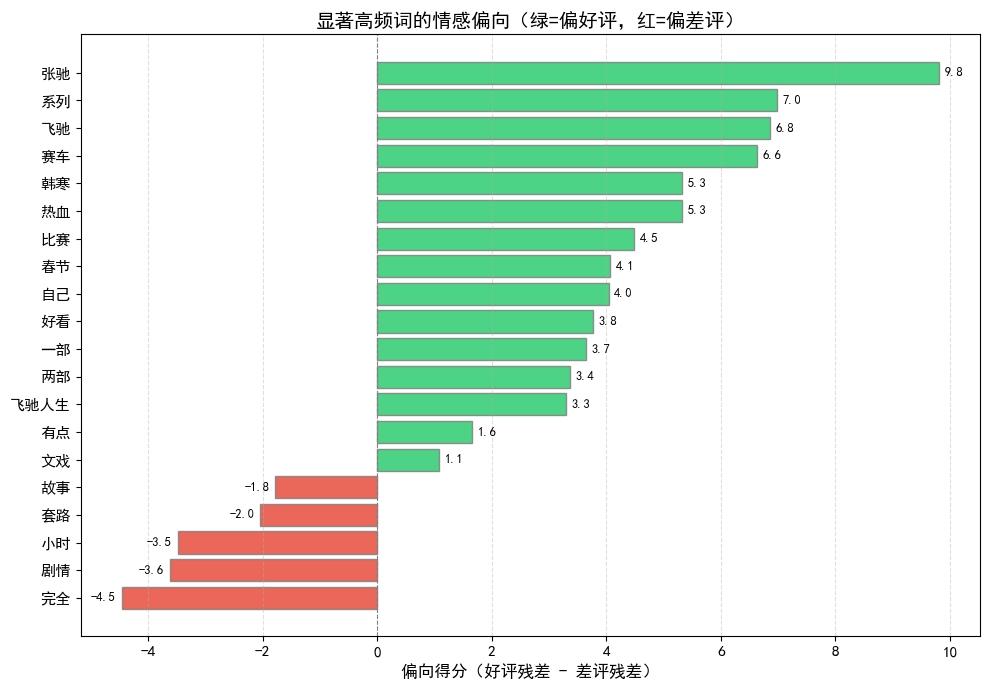

✅ 已保存：高频词_情感偏向.png


In [13]:
# 只取显著的词
sig_df = chi2_df[chi2_df["显著"] == "是"].copy()
sig_df["偏向得分"] = sig_df["好评残差"] - sig_df["差评残差"]
sig_df = sig_df.sort_values("偏向得分")

# 配色：正值偏好评（绿），负值偏差评（红）
bar_colors = ["#2ECC71" if s > 0 else "#E74C3C" for s in sig_df["偏向得分"]]

fig, ax = plt.subplots(figsize=(10, max(6, len(sig_df) * 0.35)))
ax.barh(sig_df["词"], sig_df["偏向得分"], color=bar_colors, edgecolor="gray", alpha=0.85)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("偏向得分（好评残差 - 差评残差）", fontsize=12)
ax.set_title("显著高频词的情感偏向（绿=偏好评，红=偏差评）", fontsize=14)
ax.tick_params(labelsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.4)

# 在每个柱子末端标注偏向得分
for i, (_, row) in enumerate(sig_df.iterrows()):
    score = row["偏向得分"]
    ha = "left" if score >= 0 else "right"
    offset = 0.1 if score >= 0 else -0.1
    ax.text(score + offset, i, f"{score:.1f}", va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig("高频词_情感偏向.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 已保存：高频词_情感偏向.png")

### 5.2 残差热力图：展示每个显著词在三类中的残差分布

绿色：正残差（该词在该类别中出现频率高于预期）    红色：负残差（该词在该类别中出现频率低于预期）

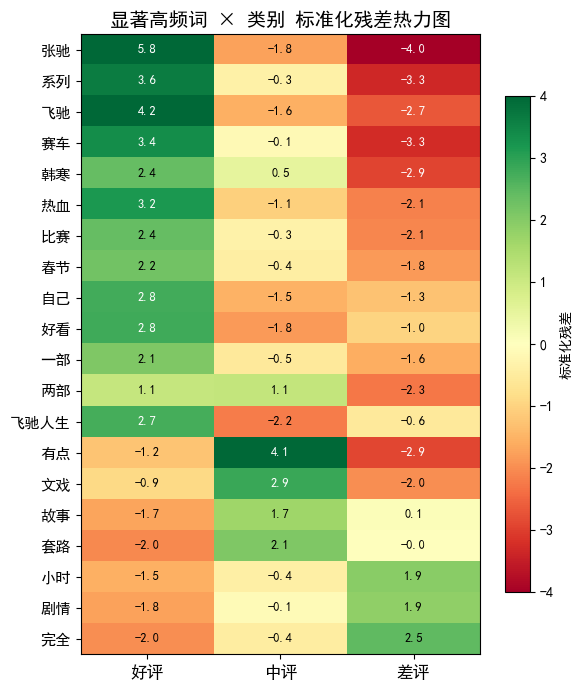

✅ 已保存：高频词_残差热力图.png


In [14]:
sig_sorted = sig_df.sort_values("偏向得分", ascending=False) # 好评偏向在上，差评偏向在下
heat_data = sig_sorted[["好评残差", "中评残差", "差评残差"]].values
heat_labels = sig_sorted["词"].values

fig, ax = plt.subplots(figsize=(6, max(6, len(sig_sorted) * 0.35)))
im = ax.imshow(heat_data, aspect="auto", cmap="RdYlGn", vmin=-4, vmax=4)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["好评", "中评", "差评"], fontsize=12)
ax.set_yticks(range(len(heat_labels)))
ax.set_yticklabels(heat_labels, fontsize=11)

# 在每个格子里标注残差值
for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        val = heat_data[i, j]
        color = "white" if abs(val) > 2.5 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")

ax.set_title("显著高频词 × 类别 标准化残差热力图", fontsize=14)
plt.colorbar(im, ax=ax, label="标准化残差", shrink=0.8)
plt.tight_layout()
plt.savefig("高频词_残差热力图.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 已保存：高频词_残差热力图.png")

## 6. 总结与结论

1. **词频层面**：三类评论在高频词选择上存在显著差异（卡方检验），
   好评偏向正面情感词，差评偏向负面表达，中评兼具两端但强度较弱。

2. **文本特征层面**：评论字数、分词数、平均句长等
   文体指标在三类间表现出统计显著差异（Kruskal-Wallis 检验）。

3. **情感层面**：基于 PMI 数据驱动构建的情感词典，三项情感指标
   （综合得分、正面词占比、负面词占比）在三类间均存在高度显著差异。
   PMI 散点图直观展示了好评/差评的特征词分布。

In [15]:
df.to_csv("飞驰人生3_analysis.csv", index=False, encoding="utf-8-sig")

print("\u2705 分析结果已保存至：飞驰人生3_analysis.csv")
print(f"   最终数据量：{len(df)} 条")
print(f"   新增字段：char_len, word_count, ttr, avg_sent_len, "
      f"pmi_score, pos_ratio, neg_ratio")
print("\n\U0001f389 全部分析完成！")

✅ 分析结果已保存至：飞驰人生3_analysis.csv
   最终数据量：1186 条
   新增字段：char_len, word_count, ttr, avg_sent_len, pmi_score, pos_ratio, neg_ratio

🎉 全部分析完成！
